In [69]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from fantasy_football.constants import PROJECT_ROOT
from fantasy_football.modelling.folds import TrainTestSplitStrategy
from fantasy_football.modelling.minutes import MinutesPredictor, MINUTES_SPEC
from fantasy_football.storage.database import get_connection    
from fantasy_football.storage.tables import MINUTES_PREDICTION, TM_PLAYER, TM_PLAYER_SEASON, TM_MARKET_VALUE, TM_TRANSFER

# Checklist

- ~~Go through Null values to inspect that they make sense~~
- [ ] Check distributions of all data
- ~~Create a train/test split~~
- [ ] Create feature for price rank position transfermarkt
- [ ] Create feature for number of players same position transfermarkt
- [ ] Create feature for price drop/increase/flat
- [ ] Create feature for count new transfers same position?

In [70]:
connection = get_connection()

In [71]:
minutes_predictor = MinutesPredictor(
    experiment_name="minutes_played_classification",
    params={},
    model_spec=MINUTES_SPEC,
    connection=connection,
    fold_strategy=TrainTestSplitStrategy(),
)

In [72]:
training_data = minutes_predictor.build_training_data()
training_data.head()

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8
"""2020-21""",1,1,8,0,"""0_minutes""",70,0.039437,4,14,100,13,3,0.0,0,2161,0.631579,4.583333,2,2,null,"""MID""",0,0
"""2020-21""",1,2,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,null,0,null,null,null,0,null,null,"""DEF""",1,0
"""2020-21""",1,3,8,0,"""0_minutes""",55,0.030986,1,13,100,12,0,0.0,0,838,0.236842,3.444444,2,2,null,"""DEF""",0,0
"""2020-21""",1,4,8,90,"""60_minutes_plus""",120,0.067606,1,14,100,13,0,71.2,0,1056,0.923077,6.916667,1,2,null,"""MID""",0,0
"""2020-21""",1,5,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,90.0,0,2794,0.815789,2.709677,2,2,null,"""DEF""",0,0


In [73]:
sql = """
WITH transfers AS (
SELECT 
     tm_player_id 
    ,joined_club
    ,transfer_date_parsed AS date_joined
    ,LEAD(transfer_date_parsed) OVER (PARTITION BY tm_player_id ORDER BY transfer_date_parsed ASC) AS date_left

FROM tm_transfer
),

market_values AS (
SELECT 
     tm_player_id
    ,value_eur
    ,value_date AS date_value_started
    ,LEAD(value_date) OVER (PARTITION BY tm_player_id ORDER BY value_date ASC) AS date_value_ended

FROM tm_market_value

UNION ALL

-- head interval, so time before a player's first valuation still joins
SELECT
     tm_player_id
    ,CAST(NULL AS BIGINT) AS value_eur
    ,CAST(NULL AS DATE) AS date_value_started
    ,MIN(value_date) AS date_value_ended

FROM tm_market_value
GROUP BY tm_player_id
)
SELECT
     tm.tm_player_id
    ,tm.name
    ,tm.position AS tm_position
    ,tf.joined_club
    ,tf.date_joined
    ,tf.date_left
    ,mv.value_eur AS value
    ,mv.date_value_started
    ,mv.date_value_ended
    ,ps.element AS fpl_element
    ,ps.season
    ,pm.gw
    ,pm.opponent
    ,pm.kickoff_time
    
FROM tm_player tm

LEFT JOIN transfers tf ON tm.tm_player_id = tf.tm_player_id
LEFT JOIN market_values mv ON tm.tm_player_id = mv.tm_player_id
    AND COALESCE(mv.date_value_started, CAST('-infinity' AS DATE)) < COALESCE(tf.date_left, CAST('infinity' AS DATE))
    AND COALESCE(mv.date_value_ended, CAST('infinity' AS DATE)) > COALESCE(tf.date_joined, CAST('-infinity' AS DATE))
LEFT JOIN tm_player_map mp ON tm.tm_player_id = mp.tm_player_id
LEFT JOIN player_season ps ON mp.player_code = ps.player_code
INNER JOIN player_match pm ON ps.element = pm.element 
    AND ps.season = pm.season
    AND pm.kickoff_time >= COALESCE(GREATEST(tf.date_joined, mv.date_value_started), CAST('-infinity' AS DATE))
    AND pm.kickoff_time < COALESCE(LEAST(tf.date_left, mv.date_value_ended), CAST('infinity' AS DATE))
LEFT JOIN player_week pw ON ps.element = pw.element
    AND ps.season = pw.season
    AND pw.gw = pm.gw

ORDER BY tm.tm_player_id, tf.date_joined, mv.date_value_started NULLS FIRST, pm.kickoff_time
"""

In [74]:
transfermarkt_data = connection.sql(sql).pl()

In [75]:
all_data = training_data.join(transfermarkt_data, left_on=["element", "season", "gw", "opponent"], right_on=["fpl_element", "season", "gw", "opponent"], how="left")
all_data.head()

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_right,date_value_started,date_value_ended,kickoff_time
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs]
"""2020-21""",1,1,8,0,"""0_minutes""",70,0.039437,4,14,100,13,3,0.0,0,2161,0.631579,4.583333,2,2,null,"""MID""",0,0,"""35664""","""Mesut Özil""","""Attacking Midfield""","""Arsenal""",2013-09-02,2021-01-25,12000000,2020-07-30,2020-10-13,2020-09-12 11:30:00
"""2020-21""",1,2,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,null,0,null,null,null,0,null,null,"""DEF""",1,0,"""34322""","""Sokratis Papastathopoulos""","""Centre-Back""","""Arsenal""",2018-07-02,2021-01-25,8000000,2020-07-30,2020-10-13,2020-09-12 11:30:00
"""2020-21""",1,3,8,0,"""0_minutes""",55,0.030986,1,13,100,12,0,0.0,0,838,0.236842,3.444444,2,2,null,"""DEF""",0,0,"""46741""","""David Luiz""","""Centre-Back""","""Arsenal""",2019-08-09,2021-09-01,8000000,2020-07-30,2020-10-13,2020-09-12 11:30:00
"""2020-21""",1,4,8,90,"""60_minutes_plus""",120,0.067606,1,14,100,13,0,71.2,0,1056,0.923077,6.916667,1,2,null,"""MID""",0,0,"""58864""","""Pierre-Emerick Aubameyang""","""Centre-Forward""","""Arsenal""",2018-01-31,2022-01-31,56000000,2020-04-08,2020-10-13,2020-09-12 11:30:00
"""2020-21""",1,5,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,90.0,0,2794,0.815789,2.709677,2,2,null,"""DEF""",0,0,"""112988""","""Cédric Soares""","""Right-Back""","""Arsenal""",2020-07-01,2023-01-31,8000000,2020-04-08,2020-10-13,2020-09-12 11:30:00


In [76]:
# will just drop null transfermarkt rows
all_data = all_data.filter(pl.col("tm_player_id").is_not_null())
all_data =all_data.rename({"value_right": "value_tm"})

In [77]:
# Share of minutes by position
tm_position_mapping = {
    "Attacking Midfield": "AM",
    "Centre-Back": "CB",
    "Centre-Forward": "ST",
    "Right-Back": "RB",
    "Goalkeeper": "GK",
    "Defensive Midfield": "CM",
    "Central Midfield": "CM",
    "Left-Back": "LB",
    "Left Midfield": "LM",
    "Left Winger": "LM",
    "Right Midfield": "RM",
    "Right Winger": "RM",
    "Second Striker": "AM"
}

all_data = all_data.with_columns(pl.col("tm_position").replace_strict(tm_position_mapping).alias("tm_position_mapped"))

all_data.head()

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs],str
"""2020-21""",1,1,8,0,"""0_minutes""",70,0.039437,4,14,100,13,3,0.0,0,2161,0.631579,4.583333,2,2,null,"""MID""",0,0,"""35664""","""Mesut Özil""","""Attacking Midfield""","""Arsenal""",2013-09-02,2021-01-25,12000000,2020-07-30,2020-10-13,2020-09-12 11:30:00,"""AM"""
"""2020-21""",1,2,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,null,0,null,null,null,0,null,null,"""DEF""",1,0,"""34322""","""Sokratis Papastathopoulos""","""Centre-Back""","""Arsenal""",2018-07-02,2021-01-25,8000000,2020-07-30,2020-10-13,2020-09-12 11:30:00,"""CB"""
"""2020-21""",1,3,8,0,"""0_minutes""",55,0.030986,1,13,100,12,0,0.0,0,838,0.236842,3.444444,2,2,null,"""DEF""",0,0,"""46741""","""David Luiz""","""Centre-Back""","""Arsenal""",2019-08-09,2021-09-01,8000000,2020-07-30,2020-10-13,2020-09-12 11:30:00,"""CB"""
"""2020-21""",1,4,8,90,"""60_minutes_plus""",120,0.067606,1,14,100,13,0,71.2,0,1056,0.923077,6.916667,1,2,null,"""MID""",0,0,"""58864""","""Pierre-Emerick Aubameyang""","""Centre-Forward""","""Arsenal""",2018-01-31,2022-01-31,56000000,2020-04-08,2020-10-13,2020-09-12 11:30:00,"""ST"""
"""2020-21""",1,5,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,90.0,0,2794,0.815789,2.709677,2,2,null,"""DEF""",0,0,"""112988""","""Cédric Soares""","""Right-Back""","""Arsenal""",2020-07-01,2023-01-31,8000000,2020-04-08,2020-10-13,2020-09-12 11:30:00,"""RB"""


In [78]:
# Register the position mapping as a view so the query isn't carrying it
tm_position_group = pl.DataFrame(
    {
        "tm_position": list(tm_position_mapping),
        "position_group": list(tm_position_mapping.values()),
    }
)
connection.register("tm_position_group", tm_position_group)

position_share_sql = """
WITH player_position AS (
SELECT
     ps.season
    ,ps.element
    ,ps.player_code
    ,pm.position_group

FROM player_season AS ps
JOIN tm_player_map AS m ON m.player_code = ps.player_code
JOIN tm_player AS tp ON tp.tm_player_id = m.tm_player_id
JOIN tm_position_group AS pm ON pm.tm_position = tp.position
),

season_minutes AS (
SELECT
     w.season
    ,w.element
    ,pp.player_code
    ,pp.position_group
    ,w.team
    ,SUM(w.minutes) AS minutes
    ,COUNT(*) FILTER (WHERE w.minutes > 0) AS games_played

FROM player_week AS w
JOIN player_position AS pp
    ON pp.season = w.season
    AND pp.element = w.element
GROUP BY ALL
),

position_share AS (
SELECT
     *
    ,SUM(minutes) OVER (PARTITION BY season, team, position_group) AS team_position_minutes
    ,minutes / NULLIF(SUM(minutes) OVER (PARTITION BY season, team, position_group), 0) AS pct_position_minutes

FROM season_minutes
),

-- Calendar previous season, not LAG over the seasons present: player_week
-- jumps 2017-18 -> 2020-21, so LAG would call 2017-18 the prior season.
seasons AS (
SELECT
     season
    ,printf('%d-%02d', CAST(LEFT(season, 4) AS INT) - 1, CAST(LEFT(season, 4) AS INT) % 100) AS prev_season

FROM (SELECT DISTINCT season FROM position_share)
)

SELECT
     c.season
    ,c.element
    ,c.player_code
    ,c.team
    ,c.position_group
    ,c.minutes
    ,c.games_played
    ,c.team_position_minutes
    ,c.pct_position_minutes
    ,p.minutes AS prev_minutes
    ,p.games_played AS prev_games_played
    ,p.pct_position_minutes AS prev_pct_position_minutes

FROM position_share AS c
JOIN seasons AS s ON s.season = c.season
LEFT JOIN position_share AS p
    ON p.season = s.prev_season
    AND p.player_code = c.player_code
    AND p.team = c.team
ORDER BY c.season DESC, c.pct_position_minutes DESC
"""

position_share = connection.sql(position_share_sql).pl()

position_share.head()


season,element,player_code,team,position_group,minutes,games_played,team_position_minutes,pct_position_minutes,prev_minutes,prev_games_played,prev_pct_position_minutes
str,i64,i64,str,str,"decimal[38,0]",i64,"decimal[38,0]",f64,"decimal[38,0]",i64,f64
"""2026-27""",548,554197,"""Sunderland""","""AM""",10,1,10,1.0,758,18,1.0
"""2026-27""",557,439509,"""Arsenal""","""LM""",76,1,76,1.0,null,null,null
"""2026-27""",233,224967,"""Everton""","""LB""",90,1,90,1.0,2959,33,1.0
"""2026-27""",264,477555,"""Fulham""","""RM""",67,1,67,1.0,566,14,0.123905
"""2026-27""",350,116535,"""Liverpool""","""GK""",90,1,90,1.0,2340,26,0.684411


In [79]:
lookback_days = 365

arrivals_sql = """
WITH spells AS (
SELECT
     t.tm_player_id
    ,t.joined_club
    ,t.transfer_date_parsed AS date_joined
    ,LEAD(t.transfer_date_parsed) OVER (PARTITION BY t.tm_player_id ORDER BY t.transfer_date_parsed ASC) AS date_left
    ,g.position_group

FROM tm_transfer AS t
JOIN tm_player AS p ON p.tm_player_id = t.tm_player_id
JOIN tm_position_group AS g ON g.tm_position = p.position
WHERE t.transfer_date_parsed IS NOT NULL
),

market_values AS (
SELECT
     tm_player_id
    ,value_eur
    ,value_date AS date_value_started
    ,LEAD(value_date) OVER (PARTITION BY tm_player_id ORDER BY value_date ASC) AS date_value_ended

FROM tm_market_value
),

fixtures AS (
SELECT
     pm.season
    ,pm.gw
    ,pm.element
    ,pm.opponent
    ,pm.kickoff_time
    ,s.tm_player_id
    ,s.joined_club
    ,s.position_group
    ,s.date_joined
    ,mv.value_eur AS player_value_eur

FROM player_match AS pm
JOIN player_season AS ps ON ps.season = pm.season AND ps.element = pm.element
JOIN tm_player_map AS mp ON mp.player_code = ps.player_code
JOIN spells AS s
    ON s.tm_player_id = mp.tm_player_id
    AND pm.kickoff_time >= s.date_joined
    AND pm.kickoff_time < COALESCE(s.date_left, CAST('infinity' AS DATE))
LEFT JOIN market_values AS mv
    ON mv.tm_player_id = s.tm_player_id
    AND pm.kickoff_time >= mv.date_value_started
    AND pm.kickoff_time < COALESCE(mv.date_value_ended, CAST('infinity' AS DATE))
),

arrivals AS (
SELECT
     f.season
    ,f.gw
    ,f.element
    ,f.opponent
    ,a.tm_player_id AS rival_tm_player_id
    ,a.date_joined AS rival_date_joined
    ,f.player_value_eur
    ,rv.value_eur AS rival_value_eur
    ,rv.value_eur / f.player_value_eur AS rival_value_share

FROM fixtures AS f
JOIN spells AS a
    ON a.joined_club = f.joined_club
    AND a.position_group = f.position_group
    AND a.tm_player_id <> f.tm_player_id
    AND a.date_joined <= f.kickoff_time
    AND a.date_joined > f.kickoff_time - INTERVAL {lookback_days} DAY
LEFT JOIN market_values AS rv
    ON rv.tm_player_id = a.tm_player_id
    AND f.kickoff_time >= rv.date_value_started
    AND f.kickoff_time < COALESCE(rv.date_value_ended, CAST('infinity' AS DATE))
)

SELECT
     f.season
    ,f.gw
    ,f.element
    ,f.opponent
    ,f.position_group
    ,f.player_value_eur
    ,COUNT(a.rival_tm_player_id) AS rivals_joined_same_pos
    ,COUNT(a.rival_tm_player_id) > 0 AS rival_joined_same_pos
    ,COUNT(*) FILTER (WHERE a.rival_value_eur > f.player_value_eur) AS higher_value_rivals_joined_same_pos
    ,COUNT(*) FILTER (WHERE a.rival_value_eur > f.player_value_eur) > 0 AS higher_value_rival_joined_same_pos
    ,MAX(a.rival_value_eur) AS max_rival_value_eur
    ,MAX(a.rival_value_share) AS max_rival_value_share
    ,MIN(date_diff('day', a.rival_date_joined, CAST(f.kickoff_time AS DATE))) AS days_since_rival_joined

FROM fixtures AS f
LEFT JOIN arrivals AS a
    ON a.season = f.season
    AND a.gw = f.gw
    AND a.element = f.element
    AND a.opponent = f.opponent
GROUP BY ALL
ORDER BY f.season DESC, f.gw, f.element
"""

position_arrivals = connection.sql(arrivals_sql.format(lookback_days=lookback_days)).pl()


In [80]:
# Join the new transfermarkt features onto all_data
#
# position_share is season grain and one row per club, so a mid-season transfer
# gives two rows per player. all_data has no team column, so collapse to the
# club the player played most minutes for that season before joining.
position_share_by_player = (
    position_share
    .sort("minutes", descending=True)
    .unique(subset=["season", "element"], keep="first")
    .select(
        "season",
        "element",
        "position_group",
        "games_played",
        "pct_position_minutes",
        "prev_pct_position_minutes",
    )
)

rows_before = all_data.height

all_data = all_data.join(
    position_share_by_player,
    on=["season", "element"],
    how="left",
).join(
    position_arrivals.drop("position_group", "player_value_eur"),
    on=["season", "gw", "element", "opponent"],
    how="left",
)

assert all_data.height == rows_before, "join fanned out"

NEW_FEATURES = [
    "games_played",
    "pct_position_minutes",
    "prev_pct_position_minutes",
    "rivals_joined_same_pos",
    "rival_joined_same_pos",
    "higher_value_rivals_joined_same_pos",
    "higher_value_rival_joined_same_pos",
    "max_rival_value_eur",
    "days_since_rival_joined",
]

print(all_data.select(NEW_FEATURES).null_count())
all_data.select(["season", "gw", "element", "tm_position"] + NEW_FEATURES).head()


shape: (1, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ games_pla ┆ pct_posit ┆ prev_pct_ ┆ rivals_jo ┆ … ┆ higher_va ┆ higher_va ┆ max_rival ┆ days_sin │
│ yed       ┆ ion_minut ┆ position_ ┆ ined_same ┆   ┆ lue_rival ┆ lue_rival ┆ _value_eu ┆ ce_rival │
│ ---       ┆ es        ┆ minutes   ┆ _pos      ┆   ┆ s_joined_ ┆ _joined_s ┆ r         ┆ _joined  │
│ u32       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ sam…      ┆ ame…      ┆ ---       ┆ ---      │
│           ┆ u32       ┆ u32       ┆ u32       ┆   ┆ ---       ┆ ---       ┆ u32       ┆ u32      │
│           ┆           ┆           ┆           ┆   ┆ u32       ┆ u32       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 462       ┆ 78715     ┆ 53        ┆ … ┆ 53        ┆ 53        ┆ 44239     ┆ 41500    │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴

season,gw,element,tm_position,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,days_since_rival_joined
str,i64,i64,str,i64,f64,f64,i64,bool,i64,bool,i64,i64
"""2020-21""",1,1,"""Attacking Midfield""",0,0.0,null,1,true,0,false,2700000,42
"""2020-21""",1,2,"""Centre-Back""",0,0.0,null,5,true,2,true,22500000,11
"""2020-21""",1,3,"""Centre-Back""",20,0.180478,null,5,true,2,true,22500000,11
"""2020-21""",1,4,"""Centre-Forward""",29,0.500322,null,1,true,0,false,15000000,254
"""2020-21""",1,5,"""Right-Back""",10,0.224231,null,0,false,0,false,null,null


In [81]:
TRAINING_SEASONS = ["2020-21", "2021-22", "2022-23", "2023-24","2024-25"]

training_data = all_data.filter(pl.col("season").is_in(TRAINING_SEASONS))
test_data = all_data.filter(~pl.col("season").is_in(TRAINING_SEASONS))

In [82]:
NUM_FEATURES = [
    "value",
    "value_share_of_team",
    "pos_value_rank",
    "players_same_pos",
    "chance_of_playing_this_round",
    "fit_rivals_same_pos",
    "fit_rivals_ahead",
    "avg_minutes_rolling_5",
    "games_played_this_season",
    "prev_season_minutes",
    "prev_season_start_rate",
    "pl_seasons_played",
    "seasons_since_last_pl",
    "age_years",
    "value_tm"
]
CAT_FEATURES = [
    "position",
    "is_pl_newcomer",
    "is_promoted_club",
    "tm_position"
]

# Analysis


In [83]:
all_data.describe()

statistic,season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped,position_group,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,max_rival_value_share,days_since_rival_joined
str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,str,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""161234""",161234.0,161234.0,161234.0,161234.0,"""161234""",161234.0,161234.0,161234.0,161234.0,161234.0,161234.0,161234.0,159521.0,161234.0,114583.0,114583.0,85796.0,161234.0,114583.0,103414.0,"""161234""",161234.0,161234.0,"""161234""","""161234""","""161234""","""161181""","""161181""","""121731""",153680.0,"""153680""","""158273""","""161234""","""161234""","""161234""",161234.0,160772.0,82519.0,161181.0,161181.0,161181.0,161181.0,116995.0,113492.0,119734.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1713.0,0.0,46651.0,46651.0,75438.0,0.0,46651.0,57820.0,"""0""",0.0,0.0,"""0""","""0""","""0""","""53""","""53""","""39503""",7554.0,"""7554""","""2961""","""0""","""0""","""0""",0.0,462.0,78715.0,53.0,53.0,53.0,53.0,44239.0,47742.0,41500.0
"""mean""",null,20.51545,362.077012,10.501972,27.961695,null,49.710898,0.02805,5.89452,12.141199,79.268486,8.452864,3.895618,28.307177,17.207121,1261.844017,0.362577,3.416942,1.773832,0.357959,25.079958,null,0.289337,0.132881,null,null,null,null,"""2021-09-29 11:16:25.984700""","""2024-05-10 08:37:29.944550""",1.6873e7,"""2023-05-21 06:58:34.357105""","""2023-10-28 11:05:44.571720""","""2023-08-25 16:06:35.388069""",null,null,14.758742,0.244752,0.298524,1.816666,0.742854,0.533562,0.328693,1.5520e7,NaN,142.885363
"""std""",null,10.980596,213.390292,5.765059,38.722257,null,11.282077,0.007276,4.253467,5.106876,39.834438,3.863285,3.327157,33.742302,10.525672,1101.177534,0.327942,1.336999,1.666471,0.817234,4.443871,null,0.453456,0.339448,null,null,null,null,null,null,2.0054e7,null,null,null,null,null,13.074514,0.290515,0.302643,1.840491,null,0.946823,null,1.6342e7,NaN,90.545751
"""min""","""2020-21""",1.0,1.0,1.0,0.0,"""0_minutes""",36.0,0.013854,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,15.060917,"""DEF""",0.0,0.0,"""10003""","""Aaron Connolly""","""Attacking Midfield""","""1.FC K'lautern""","""2006-11-17""","""2020-09-16""",0.0,"""2017-06-21""","""2020-10-08""","""2020-09-12 11:30:00""","""AM""","""AM""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,11.0,180.0,6.0,0.0,null,44.0,0.023212,2.0,9.0,100.0,6.0,1.0,0.0,8.0,90.0,0.0,2.5,0.0,0.0,21.675565,null,0.0,0.0,null,null,null,null,"""2020-07-01""","""2023-02-04""",3e6,"""2021-12-23""","""2022-06-15""","""2022-02-26 15:00:00""",null,null,0.0,0.0,0.027284,0.0,null,0.0,null,3e6,0.333333,69.0
"""50%""",null,21.0,358.0,11.0,0.0,null,46.0,0.02678,5.0,13.0,100.0,9.0,3.0,8.8,17.0,1125.0,0.315789,3.266667,1.0,0.0,24.706366,null,0.0,0.0,null,null,null,null,"""2022-06-30""","""2024-07-01""",1e7,"""2023-06-20""","""2023-12-19""","""2023-10-07 11:30:00""",null,null,14.0,0.141291,0.222185,1.0,null,0.0,null,1.1e7,1.0,125.0
"""75%""",null,30.0,537.0,15.0,76.0,null,53.0,0.031184,9.0,16.0,100.0,11.0,6.0,58.0,26.0,2186.0,0.657143,4.111111,3.0,0.0,27.989049,null,1.0,0.0,null,null,null,null,"""2023-08-31""","""2025-08-07""",2.4e7,"""2024-12-16""","""2025-05-27""","""2025-02-02 16:30:00""",null,null,27.0,0.370306,0.437975,3.0,null,1.0,null,2.2e7

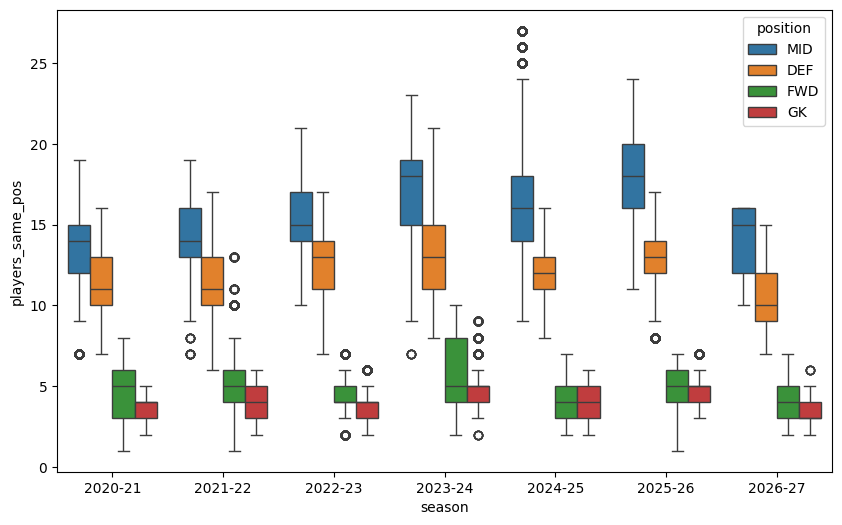

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=all_data,
    x="season",
    y="players_same_pos",
    hue="position",
    ax=ax
)

plt.show()

In [85]:
# Missing prev_season_minutes is always because they are newcomers to the league
# This is the same as prev_season_start_rate
all_data.filter((pl.col("prev_season_minutes").is_null()) & (pl.col("is_pl_newcomer") == False))

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped,position_group,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,max_rival_value_share,days_since_rival_joined
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs],str,str,i64,f64,f64,i64,bool,i64,bool,i64,f64,i64


In [86]:
# This is also the same for the rolling minutes column
all_data.filter((pl.col("avg_minutes_rolling_5").is_null()) & (pl.col("is_pl_newcomer") == False))

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped,position_group,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,max_rival_value_share,days_since_rival_joined
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs],str,str,i64,f64,f64,i64,bool,i64,bool,i64,f64,i64


In [87]:
# missing tm_player_id is where we have player missing in transfermarkt team squad for that season
# fpl has super wide squads compare to transfermarkt. This is always youth players who never play
all_data.filter(pl.col("tm_player_id").is_null())

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped,position_group,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,max_rival_value_share,days_since_rival_joined
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs],str,str,i64,f64,f64,i64,bool,i64,bool,i64,f64,i64


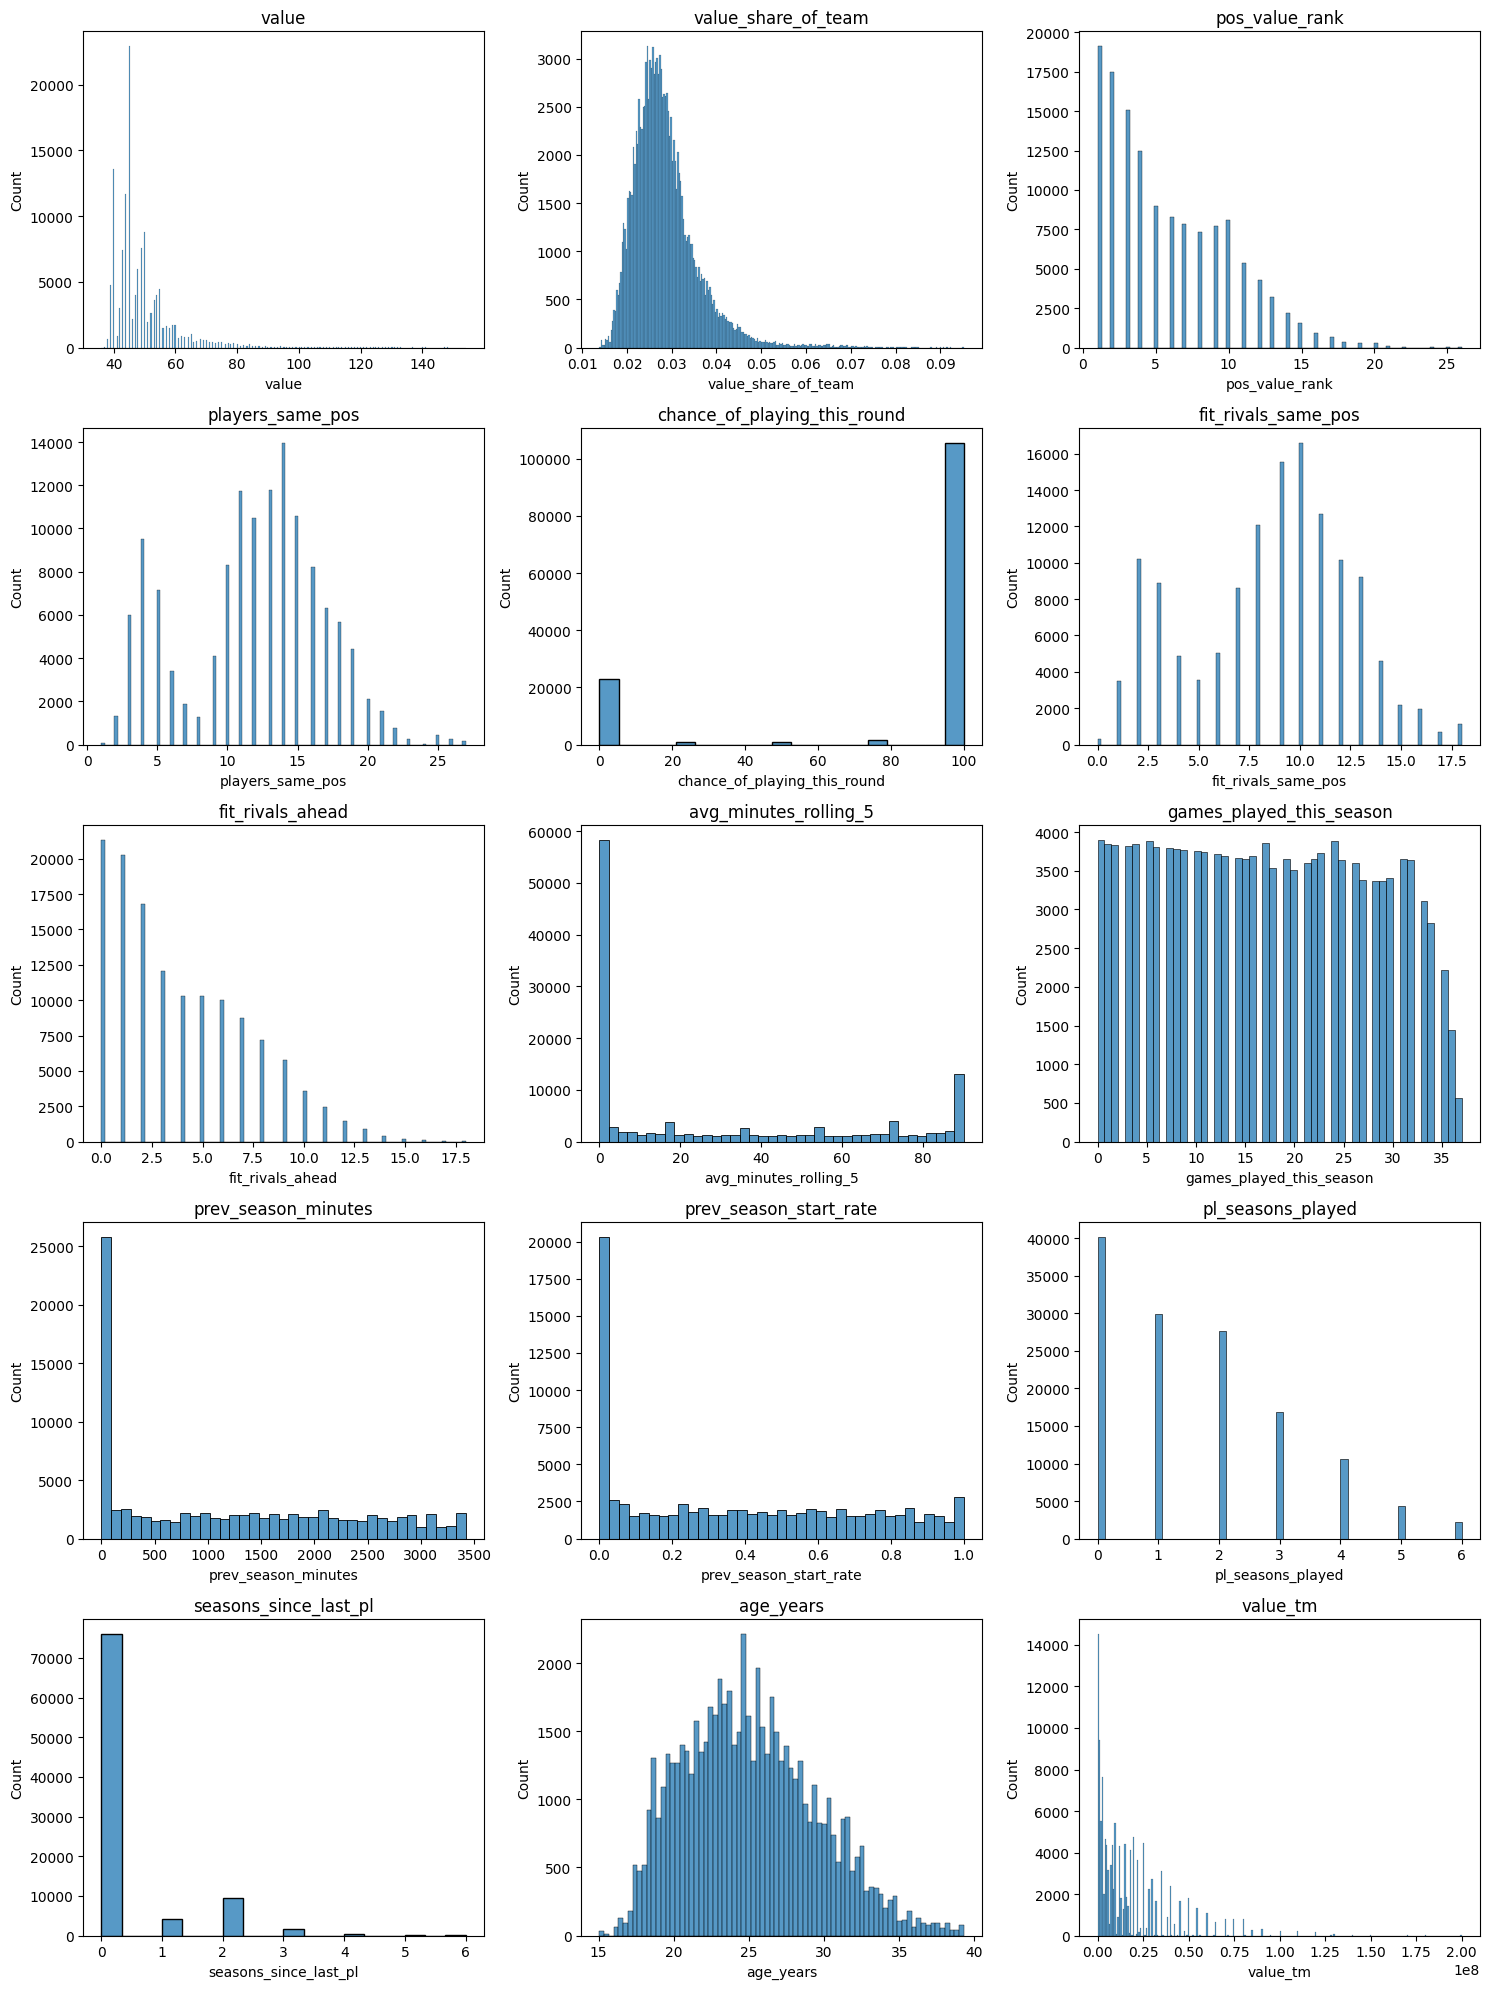

In [88]:
fig, ax = plt.subplots(5, 3, figsize=(15, 20))

for i, feature in enumerate(NUM_FEATURES):
    sns.histplot(data=training_data, x=feature, ax=ax[i // 3, i % 3])
    ax[i // 3, i % 3].set_title(feature)

plt.tight_layout()
plt.show()


In [89]:
training_data["tm_position"].value_counts(sort=True)

tm_position,count
str,u32
"""Centre-Back""",24297
"""Central Midfield""",16416
"""Centre-Forward""",16216
"""Goalkeeper""",14409
"""Right-Back""",11004
…,…
"""Right Winger""",8850
"""Attacking Midfield""",8218
"""Left Midfield""",657


# How much does value in same position impact minutes? 

What we're trying to answer here, is does the player value (as specified by transfermarkt) compared to other players in the same positions at the same club correlate or influence how many minutes that player gets? And aswell, is there positional variety in the share of minutes (i.e. do some positions tend to get rotated more).

The two hypotheses we have here are:
1. Players of the highest value in their positions are more likely to get more minutes
2. Goalkeepers and defenders are rotated less, midfielders and strikers more often rotated.

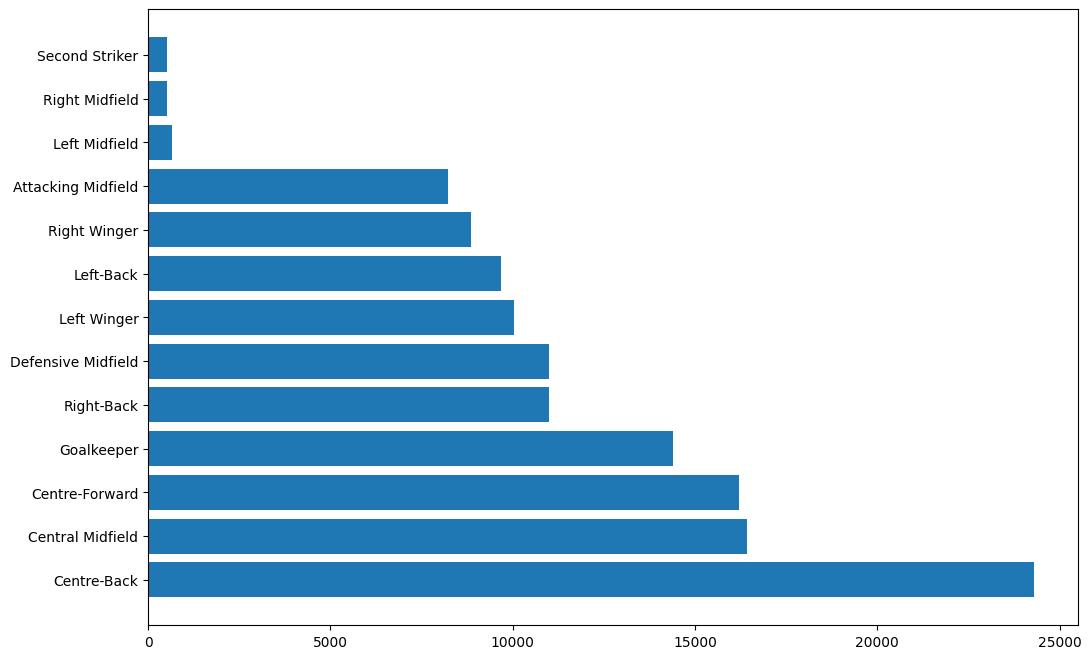

In [90]:
# transfermarkt position counts - it's a lot more granular than FPL 
# some positions should be logically grouped (i.e. Right Midfield and Right Winger - save this as an artifact to the model)
fig, ax = plt.subplots(figsize=(12, 8))

tm_position_counts = training_data["tm_position"].value_counts(sort=True)

ax.barh(tm_position_counts["tm_position"], tm_position_counts["count"])

plt.show()

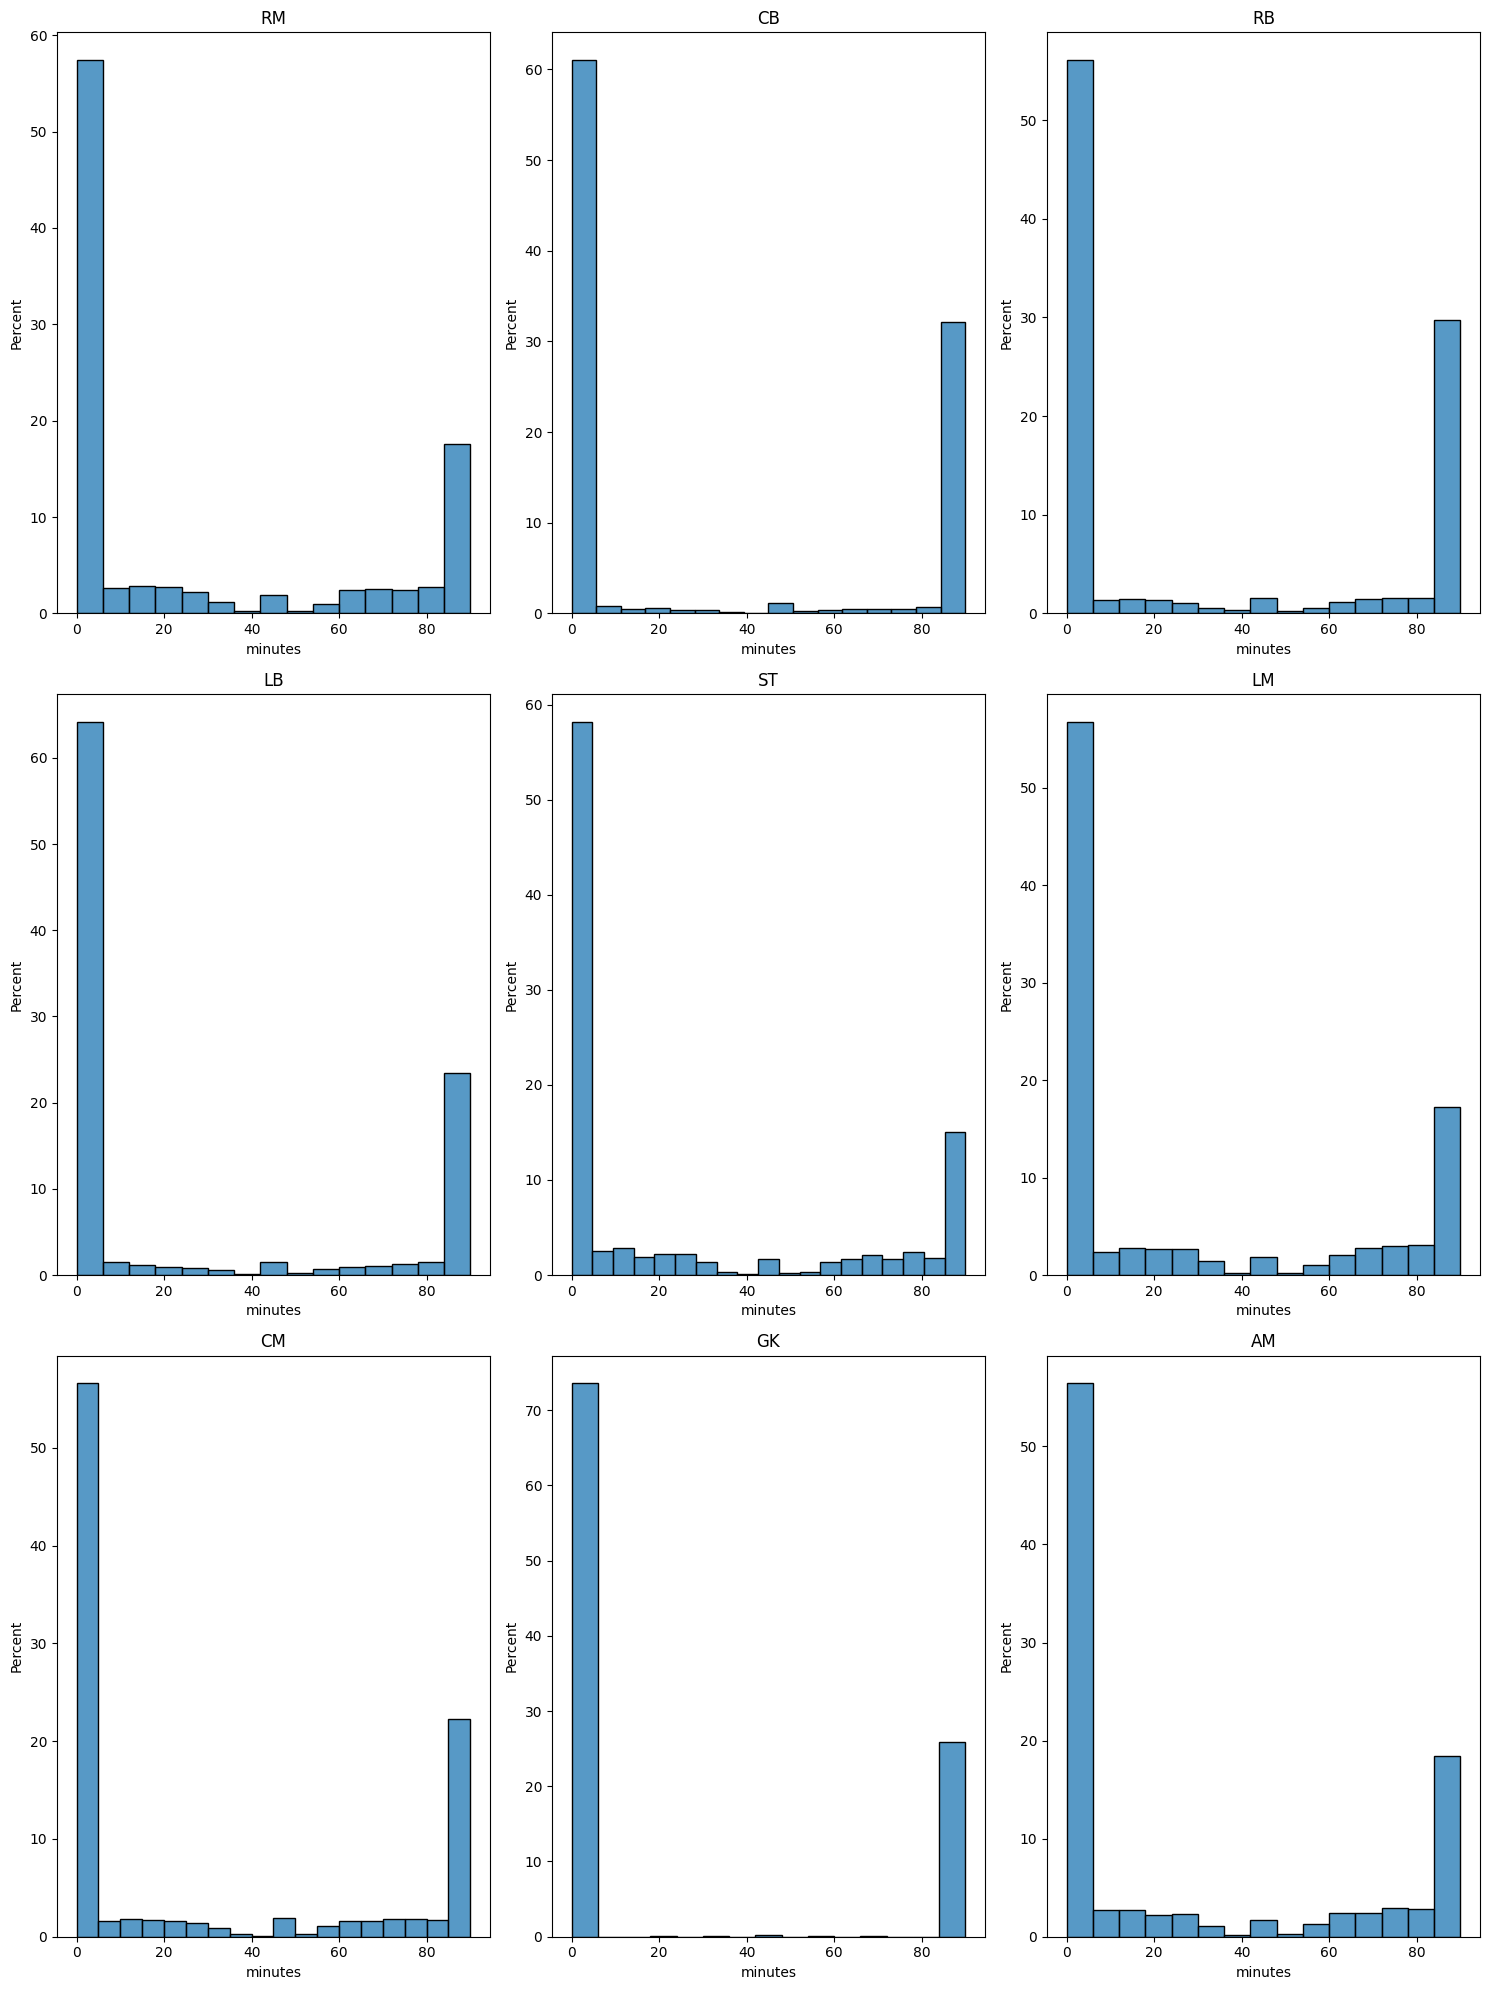

In [91]:
fig, ax = plt.subplots(3, 3, figsize=(15, 20))

for i, position in enumerate(training_data["tm_position_mapped"].unique().to_list()):
    position_subset = training_data.filter(pl.col("tm_position_mapped") == position)
    sns.histplot(data=position_subset, x="minutes", ax=ax[i // 3, i % 3], stat="percent")
    ax[i // 3, i % 3].set_title(position)

plt.tight_layout()
plt.show()
    

In [92]:
connection.close()